<a href="https://colab.research.google.com/github/vivisampelan1-sudo/Machine-Learning-/blob/main/Machine_Learning_Personal_Coursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # **A Machine Learning Approach to Volatility Forecasting**
Replication Study
Data AAPL, AMZN, JPM (2016-2023)

In [7]:
# Install and import all libraries
!pip install yfinance -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from google.colab import drive

drive.mount('/content/drive')
print("Libraries loaded and Drive mounted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries loaded and Drive mounted.


## Step 1: Data Loading and Preprocessing
Realised Variance (RV) = sum of squared intraday log returns \
per trading day, using minute-level price data.\
Overnight returns are excluded.

In [8]:
def load_and_compute_RV(filepath, stock_name):
    """Load minute-level price data and compute daily RV, volume, and momentum."""
    df = pd.read_csv(
        filepath, header=None,
        names=['Date', 'Time', 'Open', 'High', 'Low', 'Close', 'Volume']
    )

    # Parse datetime and sort
    df['DateTime'] = pd.to_datetime(
        df['Date'] + ' ' + df['Time'], format='%m/%d/%Y %H:%M'
    )
    df = df.sort_values('DateTime')
    df['Date_only'] = df['DateTime'].dt.date

    # Intraday log returns (drop overnight by matching consecutive dates)
    df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
    df = df[df['Date_only'] == df['DateTime'].shift(1).dt.date]

    # Daily aggregates
    daily_vol = (
        df.groupby('Date_only')['Volume'].sum()
        .reset_index()
        .rename(columns={'Date_only': 'Date'})
    )
    daily_vol['Date'] = pd.to_datetime(daily_vol['Date'])

    daily_close = (
        df.groupby('Date_only')['Close'].last()
        .reset_index()
        .rename(columns={'Date_only': 'Date'})
    )
    daily_close['Date'] = pd.to_datetime(daily_close['Date'])
    daily_close['M1W'] = np.log(
        daily_close['Close'] / daily_close['Close'].shift(5)
    )

    # Daily Realised Variance
    RV = (
        df.groupby('Date_only')['log_return']
        .apply(lambda x: np.sum(x**2))
        .reset_index()
        .rename(columns={'Date_only': 'Date', 'log_return': 'RV'})
    )
    RV['Date'] = pd.to_datetime(RV['Date'])
    RV['Stock'] = stock_name

    # Merge
    RV = RV.merge(daily_vol, on='Date', how='left')
    RV = RV.merge(daily_close[['Date', 'M1W']], on='Date', how='left')
    return RV


# Load all 3 stocks
BASE_PATH = '/content/drive/MyDrive/data4rv/'
STOCKS = ['AAPL', 'AMZN', 'JPM']

stock_data = {}
for ticker in STOCKS:
    stock_data[ticker] = load_and_compute_RV(
        BASE_PATH + f'{ticker}.txt', ticker
    )
    print(f"{ticker}: {len(stock_data[ticker])} trading days")

AAPL: 2264 trading days
AMZN: 2264 trading days
JPM: 2264 trading days


## Step 2: Features Construction
We build two datasets following the paper:
- MHAR features: RV_D (daily), RV_W (weekly), RV_M (monthly)
- MALL features: MHAR + VIX + Volume + Momentum (M1W)

In [9]:
# Download VIX
vix = yf.download('^VIX', start='2016-01-01', end='2023-12-31', progress=False)
vix = vix[['Close']].rename(columns={'Close': 'VIX'}).reset_index()
vix.columns = ['Date', 'VIX']
vix['Date'] = pd.to_datetime(vix['Date']).dt.tz_localize(None)
print(f"VIX downloaded: {len(vix)} days")


def build_features(df, vix_df):
    """Add HAR lag features, VIX, and the target variable."""
    df = df.sort_values('Date').reset_index(drop=True)

    # HAR lag features (all shifted by 1 to avoid look-ahead)
    df['RVD'] = df['RV'].shift(1)                           # daily lag
    df['RVW'] = df['RV'].shift(1).rolling(window=5).mean()  # weekly lag
    df['RVM'] = df['RV'].shift(1).rolling(window=22).mean() # monthly lag

    # Merge VIX
    df = df.merge(vix_df, on='Date', how='left')

    # Target: next-day RV
    df['RV_target'] = df['RV'].shift(-1)

    df = df.dropna().reset_index(drop=True)
    return df


for ticker in STOCKS:
    stock_data[ticker] = build_features(stock_data[ticker], vix)
    print(f"{ticker}: {len(stock_data[ticker])} usable observations")

VIX downloaded: 2012 days
AAPL: 1990 usable observations
AMZN: 1990 usable observations
JPM: 1990 usable observations


/tmp/ipykernel_12098/726993689.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix = yf.download('^VIX', start='2016-01-01', end='2023-12-31', progress=False)


## Step 3: Model Training and Evaluation
- Split: 70% train / 10% validation / 20% test (chronological)
- Models: HAR (OLS) vs Random Forest (500 trees)
- Metric: Relative MSE = MSE_RF / MSE_HAR  (< 1 means RF wins)

In [13]:
MHAR_FEATURES = ['RVD', 'RVW', 'RVM']
MALL_FEATURES = ['RVD', 'RVW', 'RVM', 'Volume', 'M1W', 'VIX']


def run_experiment(df, stock_name):
    """Train HAR and RF on both feature sets; return results and predictions."""
    n = len(df)
    train_end = int(n * 0.70)
    val_end = int(n * 0.80)

    train = df.iloc[:train_end]
    test = df.iloc[val_end:]

    results = {}
    predictions = {}

    for label, features in [('MHAR', MHAR_FEATURES), ('MALL', MALL_FEATURES)]:
        X_train, y_train = train[features], train['RV_target']
        X_test, y_test = test[features], test['RV_target']

        # HAR (linear regression)
        har = LinearRegression().fit(X_train, y_train)
        har_pred = har.predict(X_test)
        har_mse = mean_squared_error(y_test, har_pred)

        # Random Forest
        rf = RandomForestRegressor(n_estimators=500, random_state=42)
        rf.fit(X_train, y_train)
        rf_pred = rf.predict(X_test)
        rf_mse = mean_squared_error(y_test, rf_pred)

        results[label] = {
            'HAR_MSE': har_mse,
            'RF_MSE': rf_mse,
            'Rel_MSE': rf_mse / har_mse
        }
    # Print summary
    print(f"\n{'='*40}")
    print(f"  {stock_name}")
    print(f"{'='*40}")
    print(f"{'Dataset':<8} {'HAR MSE':<14} {'RF MSE':<14} {'RF/HAR':<8}")
    print(f"{'-'*44}")
    for label in ['MHAR', 'MALL']:
        r = results[label]
        print(f"{label:<8} {r['HAR_MSE']:<14.2e} {r['RF_MSE']:<14.2e} {r['Rel_MSE']:.4f}")

    return results, predictions


# Run experiments
all_results = {}
all_predictions = {}

print("Training models...\n")
for ticker in STOCKS:
    res, pred = run_experiment(stock_data[ticker], ticker)
    all_results[ticker] = res
    all_predictions[ticker] = pred

# Cross-stock averages
print(f"\n{'='*40}")
print("  AVERAGE ACROSS 3 STOCKS")
print(f"{'='*40}")
for dataset in ['MHAR', 'MALL']:
    avg = np.mean([all_results[t][dataset]['Rel_MSE'] for t in STOCKS])
    winner = "RF wins" if avg < 1 else "HAR wins"
    print(f"{dataset} — RF/HAR: {avg:.4f}  ({winner})")

Training models...


  AAPL
Dataset  HAR MSE        RF MSE         RF/HAR  
--------------------------------------------
MHAR     1.19e-08       1.95e-08       1.6343
MALL     1.25e-08       1.31e-08       1.0476

  AMZN
Dataset  HAR MSE        RF MSE         RF/HAR  
--------------------------------------------
MHAR     3.29e-08       5.73e-08       1.7430
MALL     3.23e-08       3.38e-08       1.0464

  JPM
Dataset  HAR MSE        RF MSE         RF/HAR  
--------------------------------------------
MHAR     1.79e-08       2.00e-08       1.1157
MALL     1.90e-08       1.41e-08       0.7443

  AVERAGE ACROSS 3 STOCKS
MHAR — RF/HAR: 1.4976  (HAR wins)
MALL — RF/HAR: 0.9461  (RF wins)


## Step 4: Results Visualization
We compare actual vs predicted RV for each stock,
and show the improvement from MHAR to MALL dataset.

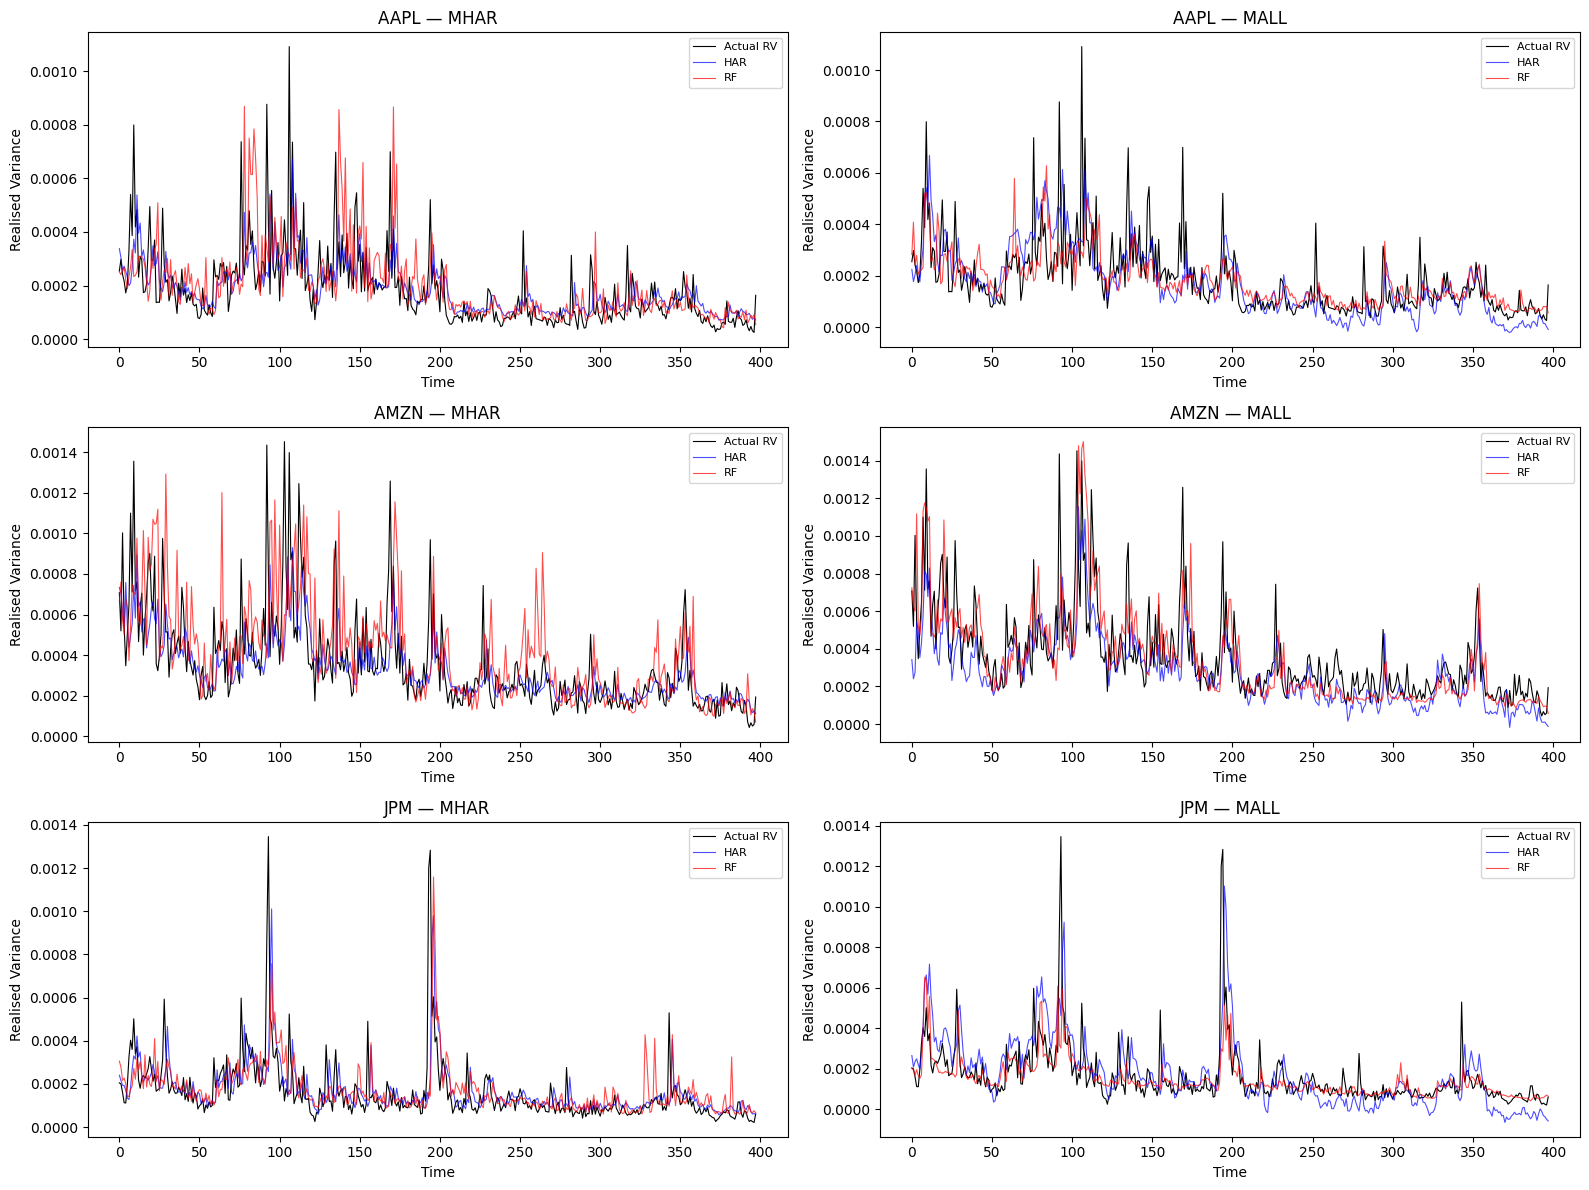

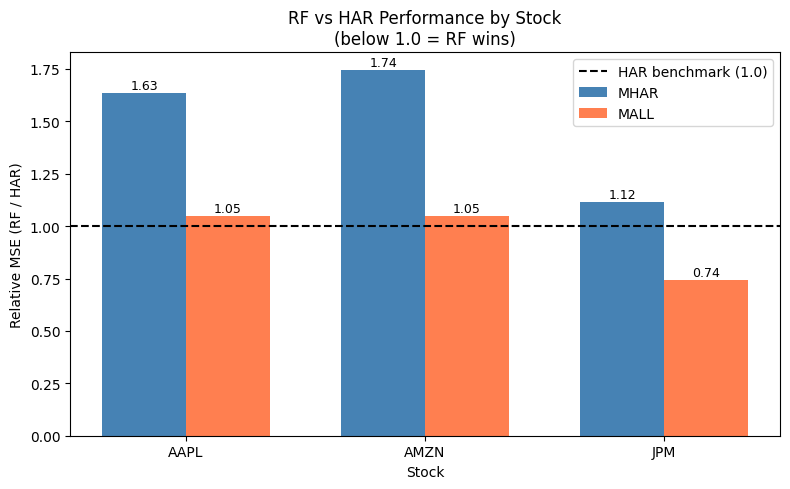


Summary Table:
  Stock  MHAR RF/HAR  MALL RF/HAR
   AAPL       1.6343       1.0476
   AMZN       1.7430       1.0464
    JPM       1.1157       0.7443
Average       1.4976       0.9461


In [11]:
# ── 4a. Actual vs Predicted RV (time series) ────────────────

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for i, ticker in enumerate(STOCKS):
    for j, dataset in enumerate(['MHAR', 'MALL']):
        ax = axes[i][j]
        preds = all_predictions[ticker][dataset]

        ax.plot(preds['y_test'].values, color='black',
                linewidth=0.8, label='Actual RV')
        ax.plot(preds['har_pred'], color='blue',
                linewidth=0.8, alpha=0.7, label='HAR')
        ax.plot(preds['rf_pred'], color='red',
                linewidth=0.8, alpha=0.7, label='RF')
        ax.set_title(f'{ticker} — {dataset}')
        ax.set_xlabel('Time')
        ax.set_ylabel('Realised Variance')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('rv_forecast_comparison.png', dpi=150)
plt.show()


# ── 4b. Relative MSE bar chart ──────────────────────────────
# (values pulled from results dict — not hardcoded)

mhar_scores = [all_results[t]['MHAR']['Rel_MSE'] for t in STOCKS]
mall_scores = [all_results[t]['MALL']['Rel_MSE'] for t in STOCKS]

x = np.arange(len(STOCKS))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, mhar_scores, width,
               label='MHAR', color='steelblue')
bars2 = ax.bar(x + width/2, mall_scores, width,
               label='MALL', color='coral')
ax.axhline(y=1.0, color='black', linestyle='--',
           linewidth=1.5, label='HAR benchmark (1.0)')

ax.set_xlabel('Stock')
ax.set_ylabel('Relative MSE (RF / HAR)')
ax.set_title('RF vs HAR Performance by Stock\n(below 1.0 = RF wins)')
ax.set_xticks(x)
ax.set_xticklabels(STOCKS)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{bar.get_height():.2f}',
                ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('stock_comparison.png', dpi=150)
plt.show()


# ── 4c. Summary table ───────────────────────────────────────

summary = pd.DataFrame({
    'Stock': STOCKS + ['Average'],
    'MHAR RF/HAR': mhar_scores + [np.mean(mhar_scores)],
    'MALL RF/HAR': mall_scores + [np.mean(mall_scores)]
})
print("\nSummary Table:")
print(summary.round(4).to_string(index=False))

# Step 5: Feature Importance Analysis
Compare importance across Ridge, Lasso, and RF
- Linear models: permutation importance (normalised)
- RF: built-in impurity-based importance

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.28153e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


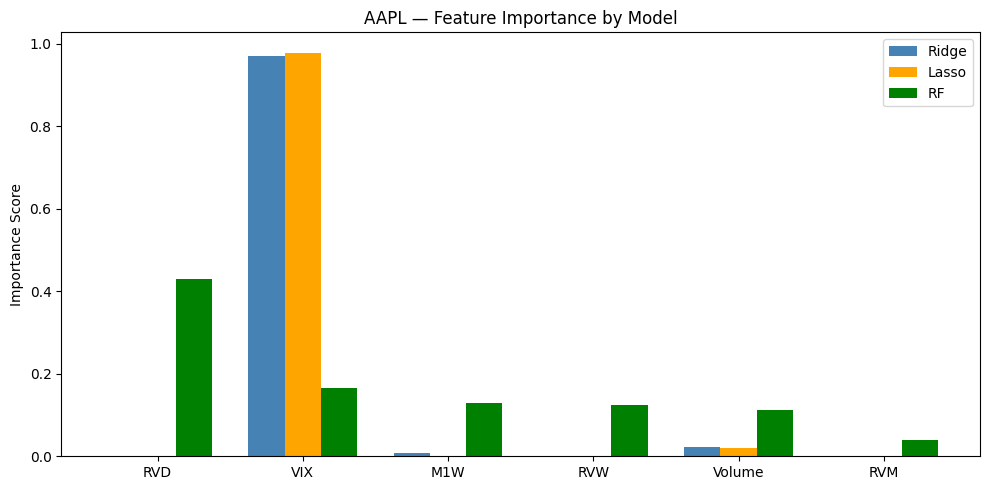


AAPL — Feature Importance:
         Ridge   Lasso      RF
RVD     0.0010  0.0000  0.4307
VIX     0.9691  0.9787  0.1649
M1W     0.0067  0.0000  0.1289
RVW     0.0008  0.0000  0.1249
Volume  0.0223  0.0213  0.1116
RVM     0.0001  0.0000  0.0391


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.26495e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


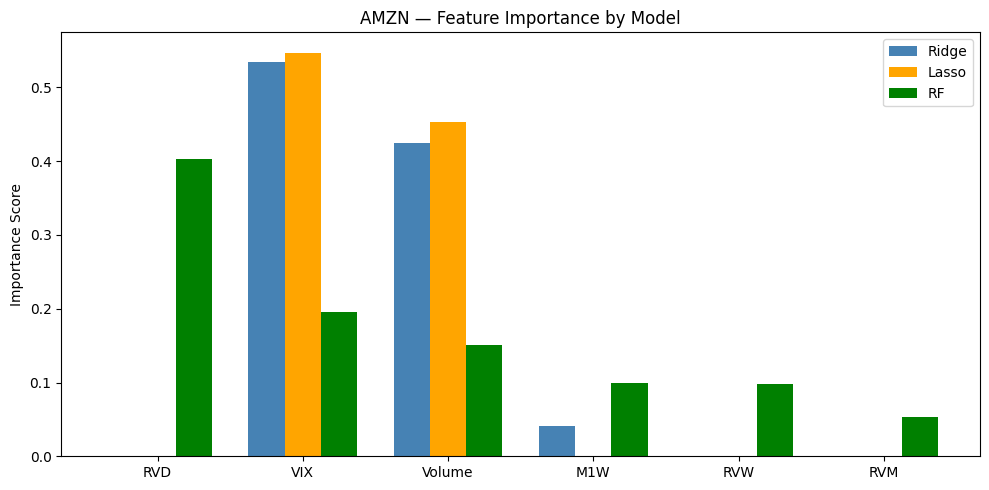


AMZN — Feature Importance:
         Ridge   Lasso      RF
RVD     0.0004  0.0000  0.4034
VIX     0.5346  0.5473  0.1961
Volume  0.4241  0.4527  0.1504
M1W     0.0407  0.0000  0.0993
RVW     0.0002  0.0000  0.0980
RVM     0.0000  0.0000  0.0527


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.72871e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


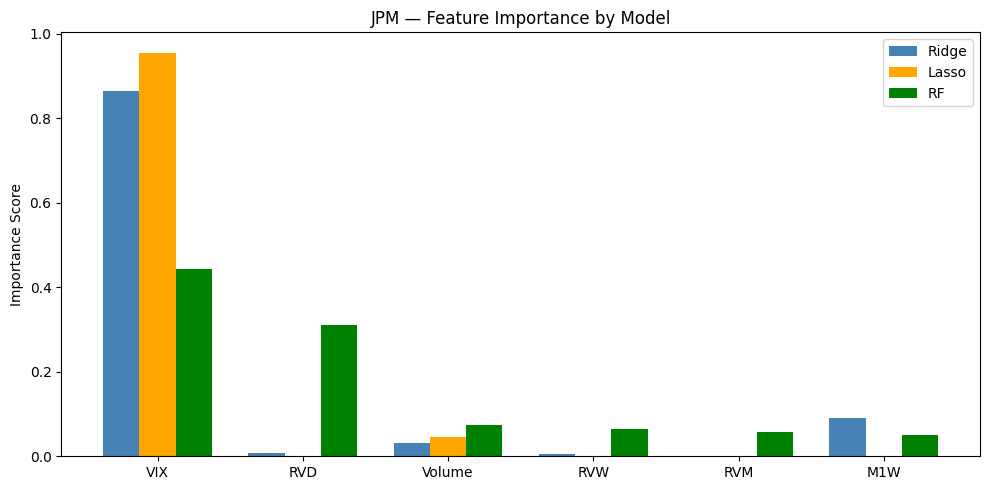


JPM — Feature Importance:
         Ridge   Lasso      RF
VIX     0.8638  0.9554  0.4420
RVD     0.0077  0.0000  0.3099
Volume  0.0318  0.0446  0.0750
RVW     0.0051  0.0000  0.0650
RVM     0.0001  0.0000  0.0578
M1W     0.0916  0.0000  0.0503


In [12]:
def compare_model_importance(df, stock_name):
    """Train Ridge, Lasso, and RF on MALL features; compare importance."""
    n = len(df)
    train = df.iloc[:int(n * 0.70)]
    test = df.iloc[int(n * 0.80):]

    X_train, y_train = train[MALL_FEATURES], train['RV_target']
    X_test, y_test = test[MALL_FEATURES], test['RV_target']

    models = {
        'Ridge': Ridge(alpha=0.01),
        'Lasso': Lasso(alpha=0.0001),
        'RF': RandomForestRegressor(n_estimators=500, random_state=42)
    }

    importance_df = pd.DataFrame(index=MALL_FEATURES)

    for name, model in models.items():
        model.fit(X_train, y_train)

        if name == 'RF':
            importance_df[name] = model.feature_importances_
        else:
            perm = permutation_importance(
                model, X_test, y_test, n_repeats=10, random_state=42
            )
            imp = np.abs(perm.importances_mean)
            importance_df[name] = imp / imp.sum()

    # Sort by RF importance
    importance_df = importance_df.sort_values('RF', ascending=False)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(MALL_FEATURES))
    width = 0.25

    ax.bar(x - width, importance_df['Ridge'], width,
           label='Ridge', color='steelblue')
    ax.bar(x, importance_df['Lasso'], width,
           label='Lasso', color='orange')
    ax.bar(x + width, importance_df['RF'], width,
           label='RF', color='green')

    ax.set_xticks(x)
    ax.set_xticklabels(importance_df.index)
    ax.set_title(f'{stock_name} — Feature Importance by Model')
    ax.set_ylabel('Importance Score')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{stock_name}_feature_importance.png', dpi=150)
    plt.show()

    print(f"\n{stock_name} — Feature Importance:")
    print(importance_df.round(4))
    return importance_df


# Run for all stocks
all_importance = {}
for ticker in STOCKS:
    all_importance[ticker] = compare_model_importance(
        stock_data[ticker], ticker
    )